<a href="https://colab.research.google.com/github/GuptaPurab/TarmacLook/blob/main/RoadDamageDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_ce9bae2ce9fce4743a2c8fdaab5ff530"

!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")
print("Dataset downloaded to:", path)

100%|██████████| 9.90G/9.90G [02:05<00:00, 85.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root, len(files), "files")
    break  # just top-level for now, avoid dumping thousands of filenames

/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1 0 files


In [ ]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level <= 2:  # limit depth so it doesn't dump thousands of filenames
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

1/  (0 files)
  RDD_SPLIT/  (0 files)
    train/  (0 files)
    test/  (0 files)
    val/  (0 files)


In [ ]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level <= 4:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

1/  (0 files)
  RDD_SPLIT/  (0 files)
    train/  (0 files)
      labels/  (26869 files)
      images/  (26869 files)
    test/  (0 files)
      labels/  (5758 files)
      images/  (5758 files)
    val/  (0 files)
      labels/  (5758 files)
      images/  (5758 files)


In [ ]:
import os

train_images = os.path.join(path, "RDD_SPLIT", "train", "images")
train_labels = os.path.join(path, "RDD_SPLIT", "train", "labels")

print("Sample image files:", os.listdir(train_images)[:5])
print("Sample label files:", os.listdir(train_labels)[:5])

# peek inside one label file to see the format
sample_label = os.listdir(train_labels)[0]
with open(os.path.join(train_labels, sample_label), 'r') as f:
    print(f"\nContents of {sample_label}:")
    print(f.read())

Sample image files: ['India_003732.jpg', 'Norway_004557.jpg', 'India_005917.jpg', 'India_003922.jpg', 'India_007218.jpg']
Sample label files: ['India_004331.txt', 'Norway_003715.txt', 'United_States_002099.txt', 'Czech_002326.txt', 'Japan_004245.txt']

Contents of India_004331.txt:
4 0.479167 0.673611 0.041667 0.038889
4 0.152083 0.688889 0.284722 0.138889
2 0.490278 0.763194 0.361111 0.273611
0 0.656944 0.778472 0.075000 0.198611



In [ ]:
import os
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

base = os.path.join(path, "RDD_SPLIT")
splits = ["train", "val", "test"]

# ---------- 1. Parse everything into a dataframe ----------
records = []
for split in splits:
    labels_dir = os.path.join(base, split, "labels")
    for fname in os.listdir(labels_dir):
        country = re.match(r"([A-Za-z_]+)_\d+", fname).group(1)
        with open(os.path.join(labels_dir, fname), 'r') as f:
            lines = f.readlines()
        if len(lines) == 0:
            records.append({"split": split, "country": country, "file": fname,
                             "class_id": None, "width": None, "height": None})
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                records.append({
                    "split": split, "country": country, "file": fname,
                    "class_id": int(cls), "width": float(w), "height": float(h)
                })

df = pd.DataFrame(records)
print("Total annotation rows:", len(df))
print("Unique classes found:", sorted(df['class_id'].dropna().unique()))
print("\nImages with NO annotations (empty label files):", df['class_id'].isna().sum())


Total annotation rows: 77436
Unique classes found: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Images with NO annotations (empty label files): 11724



Class distribution:
 class_id
0.0    26016
1.0    11830
2.0    10617
3.0    10705
4.0     6544
Name: count, dtype: int64


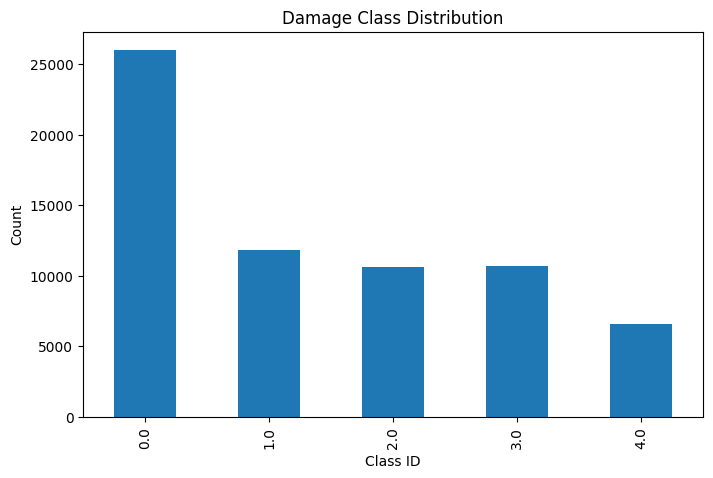

In [ ]:
class_counts = df['class_id'].dropna().value_counts().sort_index()
print("\nClass distribution:\n", class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title("Damage Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.savefig("class_distribution.png")
plt.show()


Images per country:
 country
China_Drone         2401
China_MotorBike     1977
Czech               2829
India               7706
Japan              10506
Norway              8161
United_States       4805
Name: file, dtype: int64


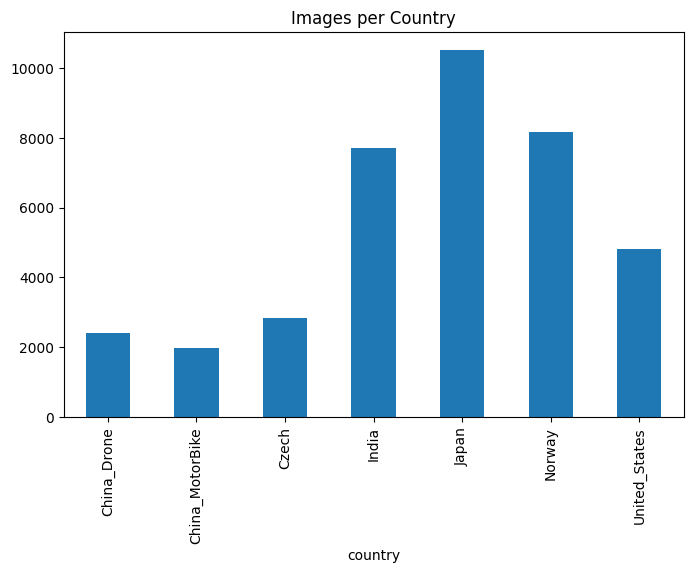

In [ ]:
country_counts = df.groupby('country')['file'].nunique()
print("\nImages per country:\n", country_counts)

plt.figure(figsize=(8,5))
country_counts.plot(kind='bar')
plt.title("Images per Country")
plt.savefig("country_distribution.png")
plt.show()


Class distribution by country:
 class_id          0.0   1.0   2.0   3.0   4.0
country                                      
China_Drone      1426  1263   293   772    86
China_MotorBike  2678  1096   641   277   235
Czech             988   399   161     0   197
India            1555    68  2021  1372  3187
Japan            4049  3979  6199  8284  2243
Norway           8570  1730   468     0   461
United_States    6750  3295   834     0   135


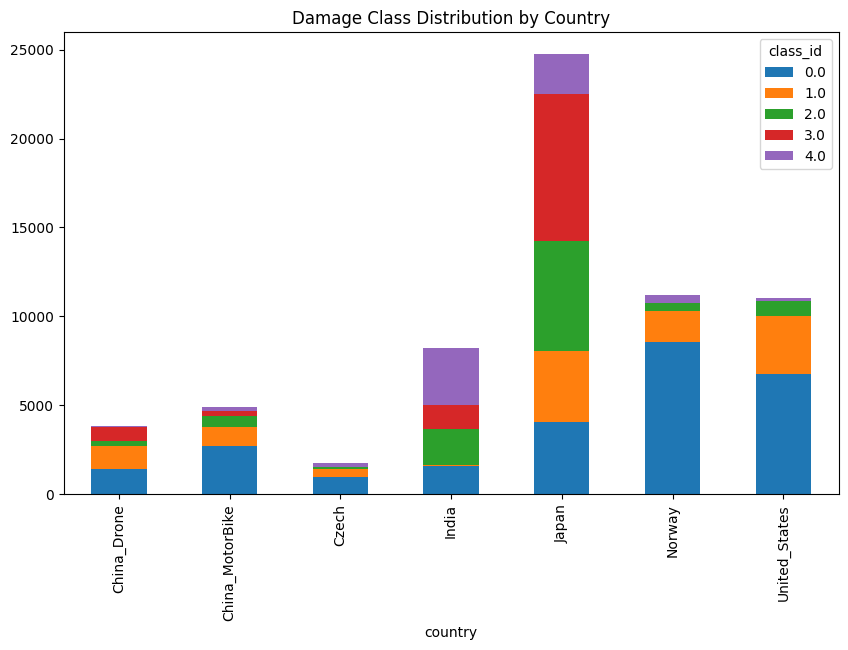

In [ ]:
cross = pd.crosstab(df['country'], df['class_id'])
print("\nClass distribution by country:\n", cross)

cross.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Damage Class Distribution by Country")
plt.savefig("class_by_country.png")
plt.show()

/tmp/ipykernel_4350/1176057494.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_boxes['area'] = df_boxes['width'] * df_boxes['height']



Bounding box area stats (normalized):
 count    65712.000000
mean         0.046118
std          0.079648
min          0.000000
25%          0.004825
50%          0.015176
75%          0.049783
max          0.940847
Name: area, dtype: float64


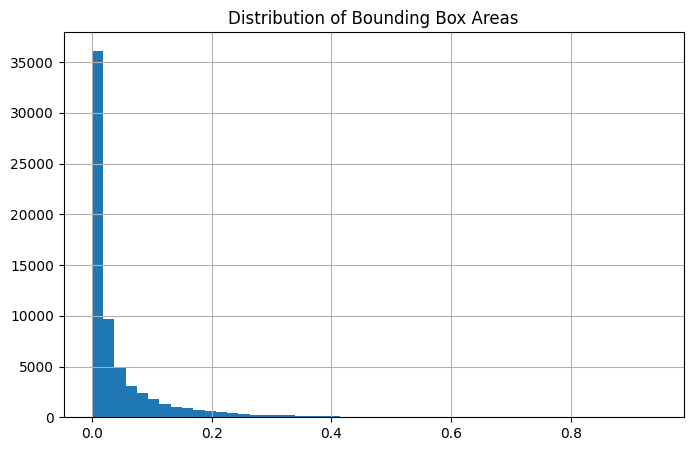

In [ ]:
df_boxes = df.dropna(subset=['width', 'height'])
df_boxes['area'] = df_boxes['width'] * df_boxes['height']

print("\nBounding box area stats (normalized):\n", df_boxes['area'].describe())

plt.figure(figsize=(8,5))
df_boxes['area'].hist(bins=50)
plt.title("Distribution of Bounding Box Areas")
plt.savefig("bbox_area_dist.png")
plt.show()


Objects per image stats:
 count    38385.000000
mean         1.711919
std          2.054314
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         44.000000
Name: class_id, dtype: float64


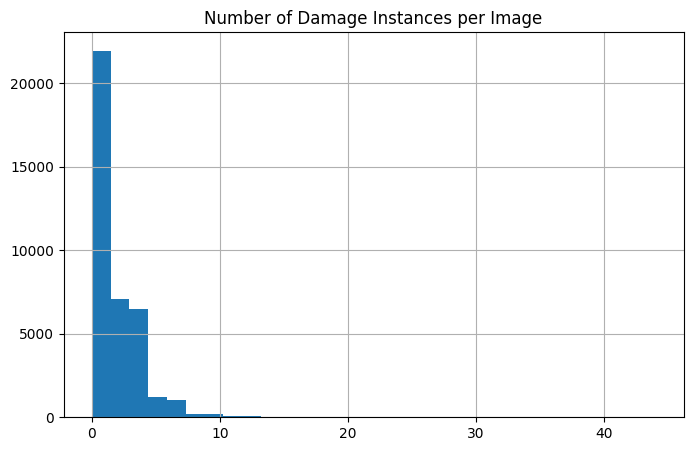

In [ ]:
objs_per_image = df.groupby('file')['class_id'].count()
print("\nObjects per image stats:\n", objs_per_image.describe())

plt.figure(figsize=(8,5))
objs_per_image.hist(bins=30)
plt.title("Number of Damage Instances per Image")
plt.savefig("objects_per_image.png")
plt.show()

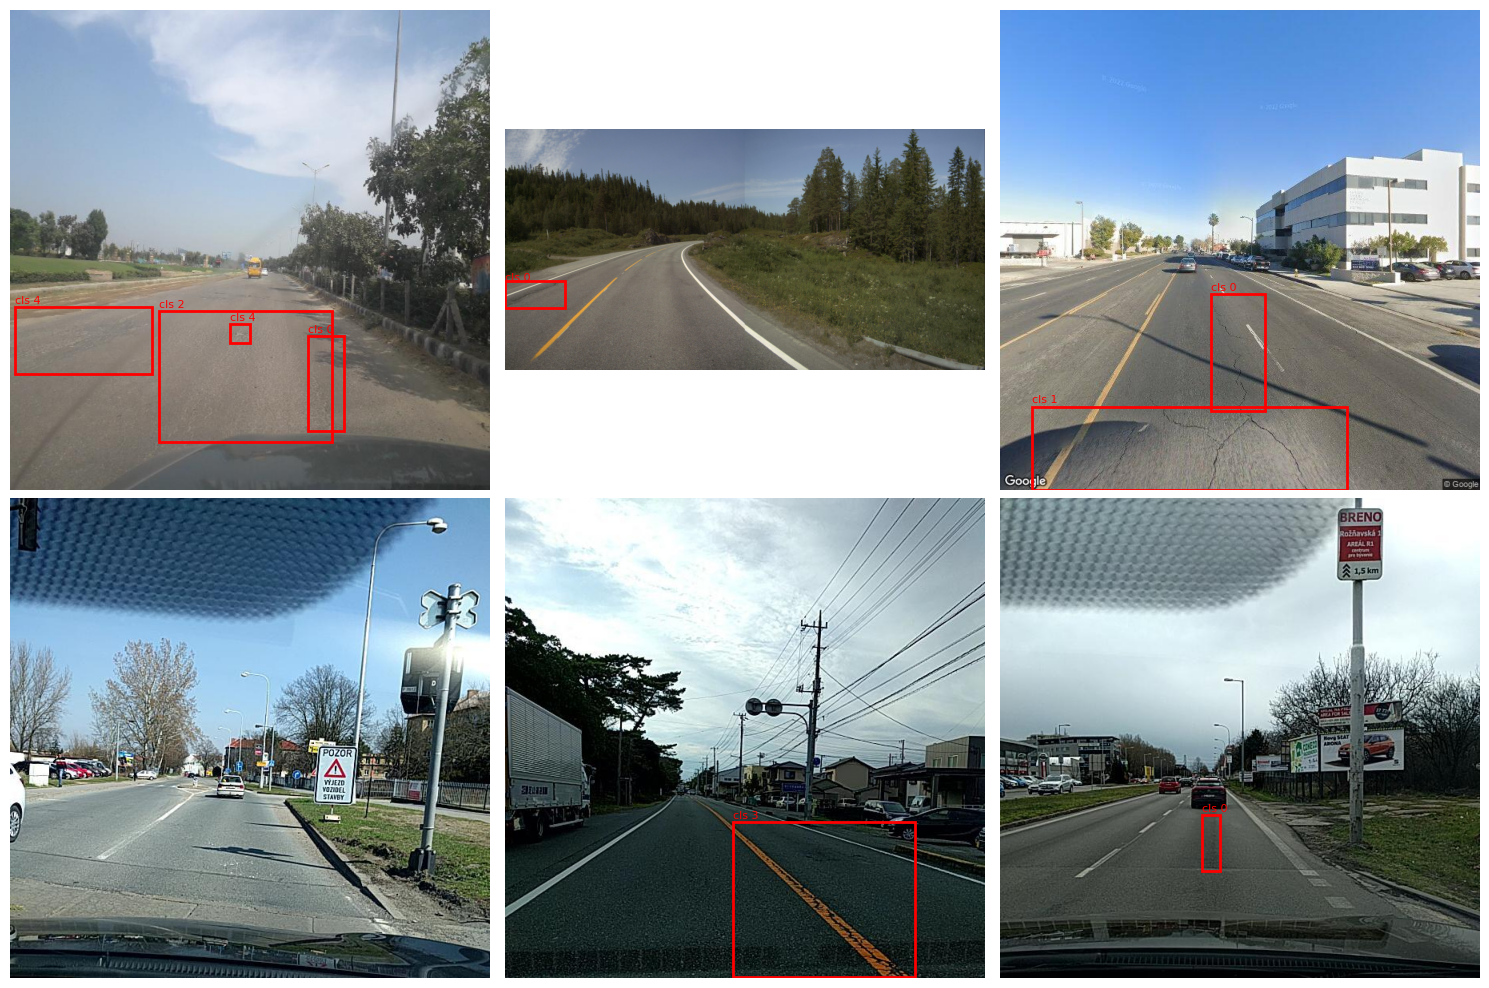

In [ ]:
import matplotlib.patches as patches

def show_sample(img_path, label_path, ax):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    with open(label_path) as f:
        for line in f.readlines():
            cls, xc, yc, w, h = map(float, line.strip().split())
            x1 = (xc - w/2) * W
            y1 = (yc - h/2) * H
            rect = patches.Rectangle((x1, y1), w*W, h*H, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"cls {int(cls)}", color='red', fontsize=8)
    ax.axis('off')

train_img_dir = os.path.join(base, "train", "images")
train_lbl_dir = os.path.join(base, "train", "labels")
sample_files = [f for f in os.listdir(train_lbl_dir)][:6]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
for ax, fname in zip(axes.flatten(), sample_files):
    img_file = fname.replace('.txt', '.jpg')
    show_sample(os.path.join(train_img_dir, img_file), os.path.join(train_lbl_dir, fname), ax)
plt.tight_layout()
plt.savefig("sample_annotations.png")
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, hamming_loss
from tqdm import tqdm

In [ ]:
base = os.path.join(path, "RDD_SPLIT")
NUM_CLASSES = 5
IMG_SIZE = 128          # resize target, keeps HOG fast
TRAIN_SUBSAMPLE = 8000  # cap on training images for feasible Colab runtime
VAL_SUBSAMPLE = 2000
TEST_SUBSAMPLE = 2000

In [ ]:
# ---------- 1. Build multilabel vectors from YOLO label files ----------
def build_label_df(split):
    labels_dir = os.path.join(base, split, "labels")
    images_dir = os.path.join(base, split, "images")
    records = []
    for fname in os.listdir(labels_dir):
        label_vec = np.zeros(NUM_CLASSES, dtype=int)
        with open(os.path.join(labels_dir, fname), 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls = int(parts[0])
                label_vec[cls] = 1
        img_file = fname.replace('.txt', '.jpg')
        records.append({
            "img_path": os.path.join(images_dir, img_file),
            "labels": label_vec
        })
    return pd.DataFrame(records)

print("Building label dataframes...")
train_df = build_label_df("train")
val_df = build_label_df("val")
test_df = build_label_df("test")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Building label dataframes...
Train: 26869, Val: 5758, Test: 5758


In [ ]:
# ---------- 2. Subsample for feasible runtime ----------
np.random.seed(42)
train_df = train_df.sample(n=min(TRAIN_SUBSAMPLE, len(train_df)), random_state=42).reset_index(drop=True)
val_df = val_df.sample(n=min(VAL_SUBSAMPLE, len(val_df)), random_state=42).reset_index(drop=True)
test_df = test_df.sample(n=min(TEST_SUBSAMPLE, len(test_df)), random_state=42).reset_index(drop=True)
print(f"After subsampling -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


After subsampling -> Train: 8000, Val: 2000, Test: 2000


In [ ]:
# ---------- 3. Feature extraction: HOG on resized grayscale images ----------
def extract_hog_features(df):
    features = []
    for img_path in tqdm(df['img_path'], desc="Extracting HOG"):
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        gray = rgb2gray(np.array(img))
        feat = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                    cells_per_block=(2, 2), block_norm='L2-Hys')
        features.append(feat)
    return np.array(features)

print("\nExtracting features for train set...")
X_train = extract_hog_features(train_df)
print("Extracting features for val set...")
X_val = extract_hog_features(val_df)
print("Extracting features for test set...")
X_test = extract_hog_features(test_df)

y_train = np.stack(train_df['labels'].values)
y_val = np.stack(val_df['labels'].values)
y_test = np.stack(test_df['labels'].values)

print(f"\nFeature shape: {X_train.shape}")  # (n_samples, n_hog_features)


Extracting features for train set...


Extracting HOG: 100%|██████████| 8000/8000 [06:13<00:00, 21.39it/s]


Extracting features for val set...


Extracting HOG: 100%|██████████| 2000/2000 [01:35<00:00, 21.00it/s]


Extracting features for test set...


Extracting HOG: 100%|██████████| 2000/2000 [01:27<00:00, 22.78it/s]


Feature shape: (8000, 1764)


In [ ]:
# ---------- 4. Train multilabel SVM ----------
print("\nTraining OneVsRestClassifier(LinearSVC)...")
clf = OneVsRestClassifier(LinearSVC(max_iter=5000, class_weight='balanced'))
clf.fit(X_train, y_train)


Training OneVsRestClassifier(LinearSVC)...


OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced', max_iter=5000))

In [ ]:
# ---------- 5. Evaluate on val set first (sanity check before touching test) ----------
print("\n--- Validation Set Results ---")
y_val_pred = clf.predict(X_val)
class_names = ['Longitudinal Crack', 'Transverse Crack', 'Alligator Crack', 'Other Corruption', 'Pothole']
print(classification_report(y_val, y_val_pred, target_names=class_names, zero_division=0))
print("Macro-F1:", f1_score(y_val, y_val_pred, average='macro', zero_division=0))
print("Micro-F1:", f1_score(y_val, y_val_pred, average='micro', zero_division=0))
print("Hamming Loss:", hamming_loss(y_val, y_val_pred))



--- Validation Set Results ---
                    precision    recall  f1-score   support

Longitudinal Crack       0.52      0.63      0.57       681
  Transverse Crack       0.35      0.57      0.43       385
   Alligator Crack       0.39      0.63      0.48       412
  Other Corruption       0.46      0.70      0.56       391
           Pothole       0.21      0.48      0.29       189

         micro avg       0.41      0.62      0.49      2058
         macro avg       0.39      0.60      0.47      2058
      weighted avg       0.42      0.62      0.50      2058
       samples avg       0.32      0.42      0.34      2058

Macro-F1: 0.46700827956013435
Micro-F1: 0.4895212459142473
Hamming Loss: 0.2655


In [ ]:
# ---------- 6. Final evaluation on test set ----------
print("\n--- Test Set Results (final baseline numbers) ---")
y_test_pred = clf.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))
print("Macro-F1:", f1_score(y_test, y_test_pred, average='macro', zero_division=0))
print("Micro-F1:", f1_score(y_test, y_test_pred, average='micro', zero_division=0))
print("Hamming Loss:", hamming_loss(y_test, y_test_pred))


--- Test Set Results (final baseline numbers) ---
                    precision    recall  f1-score   support

Longitudinal Crack       0.57      0.67      0.61       745
  Transverse Crack       0.35      0.61      0.45       389
   Alligator Crack       0.37      0.62      0.46       413
  Other Corruption       0.44      0.63      0.52       381
           Pothole       0.20      0.51      0.29       175

         micro avg       0.41      0.63      0.50      2103
         macro avg       0.39      0.61      0.47      2103
      weighted avg       0.44      0.63      0.51      2103
       samples avg       0.33      0.43      0.35      2103

Macro-F1: 0.4667344271912956
Micro-F1: 0.49539213842392327
Hamming Loss: 0.2683


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/road_damage_project', exist_ok=True)

import joblib
joblib.dump(clf, '/content/drive/MyDrive/road_damage_project/svm_baseline.pkl')
np.save('/content/drive/MyDrive/road_damage_project/X_train.npy', X_train)
np.save('/content/drive/MyDrive/road_damage_project/y_train.npy', y_train)
np.save('/content/drive/MyDrive/road_damage_project/X_val.npy', X_val)
np.save('/content/drive/MyDrive/road_damage_project/y_val.npy', y_val)
np.save('/content/drive/MyDrive/road_damage_project/X_test.npy', X_test)
np.save('/content/drive/MyDrive/road_damage_project/y_test.npy', y_test)

print("Checkpoint saved successfully.")

Checkpoint saved successfully.
